# MNIST Digit Model

In [34]:
from sklearn.datasets import fetch_openml

# Load the MNIST dataset
mnist = fetch_openml('mnist_784', version=1)
X, y = mnist['data'], mnist['target']

In [35]:
X.head()

,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [36]:
y.head()

0    5
1    0
2    4
3    1
4    9
Name: class, dtype: category
Categories (10, str): ['0', '1', '2', '3', ..., '6', '7', '8', '9']

In [37]:
import matplotlib.pyplot as plt

In [38]:
import numpy as np
import pandas as pd

In [39]:
X_array = np.array(X)
X_array

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(70000, 784))

In [40]:
example = X_array[0].reshape(28, 28)
example

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  

In [41]:
example.shape

(28, 28)

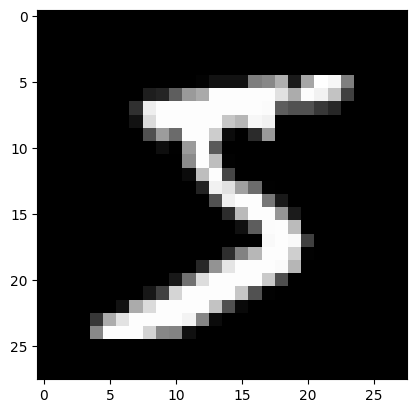

In [42]:
plt.imshow(example, cmap='gray')

In [43]:
y[1]

'0'

In [44]:
y.value_counts()

class
1    7877
7    7293
3    7141
2    6990
9    6958
0    6903
6    6876
8    6825
4    6824
5    6313
Name: count, dtype: int64

In [45]:
import torch

In [46]:
y_array = np.array(y, dtype=int)
y_array

array([5, 0, 4, ..., 4, 5, 6], shape=(70000,))

In [47]:
# convert our X and y into tensors
X = torch.tensor(X_array, dtype=torch.float)
y = torch.tensor(y_array, dtype=torch.long)

In [48]:
X, y

(tensor([[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]),
 tensor([5, 0, 4,  ..., 4, 5, 6]))

- Train test split

In [49]:
from sklearn.model_selection import train_test_split 

In [50]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [51]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

(torch.Size([56000, 784]),
 torch.Size([14000, 784]),
 torch.Size([56000]),
 torch.Size([14000]))

# Model training

In [52]:
import torch.nn as nn

In [53]:
class MNISTModel(nn.Module):
    def __init__(self, input_dim=784, hidden_1=392, hidden_2=196, hidden_3=98, hidden_4=49, hidden_5=24, output_dim=10):
        super(MNISTModel, self).__init__()

        # layers 
        self.fc1 = nn.Linear(input_dim, hidden_1) # input layer 

        # hidden state - start 
        self.fc2 = nn.Linear(hidden_1, hidden_2)
        self.relu1 = nn.ReLU()

        self.fc3 = nn.Linear(hidden_2, hidden_3)
        self.relu2 = nn.ReLU()

        self.fc4 = nn.Linear(hidden_3, hidden_4)
        self.relu3 = nn.ReLU()

        self.fc5 = nn.Linear(hidden_4, hidden_5)
        self.relu4 = nn.ReLU()

        self.fc6 = nn.Linear(hidden_5, output_dim)

    def forward(self, x):
        x = self.fc1(x)

        x = self.fc2(x)
        x = self.relu1(x)

        x = self.fc3(x)
        x = self.relu2(x)

        x = self.fc4(x)
        x = self.relu3(x)

        x = self.fc5(x)
        x = self.relu4(x)

        x = self.fc6(x)

        return x

In [54]:
model = MNISTModel()
model

MNISTModel(
  (fc1): Linear(in_features=784, out_features=392, bias=True)
  (fc2): Linear(in_features=392, out_features=196, bias=True)
  (relu1): ReLU()
  (fc3): Linear(in_features=196, out_features=98, bias=True)
  (relu2): ReLU()
  (fc4): Linear(in_features=98, out_features=49, bias=True)
  (relu3): ReLU()
  (fc5): Linear(in_features=49, out_features=24, bias=True)
  (relu4): ReLU()
  (fc6): Linear(in_features=24, out_features=10, bias=True)
)

In [55]:
loss_function = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [56]:
X_train.shape

torch.Size([56000, 784])

In [57]:
epoches = 101

for epoch in range(epoches):
    model.train()

    out = model(X_train)
    loss = loss_function(out, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 10 == 0:
        print("Epoch: ", epoch, "Loss: ", loss.item())


Epoch:  0 Loss:  2.5951056480407715
Epoch:  10 Loss:  0.953026294708252
Epoch:  20 Loss:  0.4289732277393341
Epoch:  30 Loss:  0.2856399416923523
Epoch:  40 Loss:  0.20896939933300018
Epoch:  50 Loss:  0.15942421555519104
Epoch:  60 Loss:  0.12583325803279877
Epoch:  70 Loss:  0.11254561692476273
Epoch:  80 Loss:  0.08762496709823608
Epoch:  90 Loss:  0.07280266284942627
Epoch:  100 Loss:  0.06171296909451485


In [58]:
from sklearn.metrics import accuracy_score

In [59]:
y_pred = model(X_test)
y_pred = y_pred.argmax(dim=1)
y_pred

tensor([8, 4, 8,  ..., 2, 7, 1])

In [60]:
accuracy_score(y_pred, y_test)

0.967

In [70]:
random_X = X_test[11]
random_X_reshape = np.array(random_X).reshape(28, 28)
random_X_reshape.shape

/tmp/ipykernel_6424/1022142228.py:2: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  random_X_reshape = np.array(random_X).reshape(28, 28)


(28, 28)

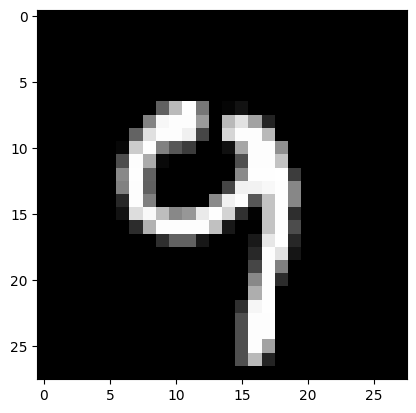

In [71]:
plt.imshow(random_X_reshape, cmap="gray");

In [72]:
out = model(random_X)
out

tensor([-0.2224,  6.2967,  4.6138,  4.9812,  7.4142,  2.2453, -0.3568,  8.7169,
         4.7408, 15.4305], grad_fn=<ViewBackward0>)

In [73]:
out.argmax(dim=0)

tensor(9)